# KNN — Predict Whether a Person Will Have Diabetes

## Import all dependencies

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Load diabetes.csv

In [3]:
dataset = pd.read_csv('diabetes.csv')

## Examine the dataset

In [4]:
print('Rows:', len(dataset))
# Pregnancies = number of times the person has been pregnant
# Outcome = 1 means diabetic, 0 means not diabetic
dataset.head()

Rows: 768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Processing

Some columns contain `0` as a placeholder for missing values — a glucose level or BMI of 0 is physiologically impossible. We replace these zeros with each column's mean.

In [6]:
zero_not_accepted = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']

### Replace zeros with the column mean

In [7]:
for column in zero_not_accepted:
    dataset[column] = dataset[column].replace(0, np.nan)
    mean = round(dataset[column].mean(skipna=True), 1)
    dataset[column] = dataset[column].replace(np.nan, mean)

dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686849,72.404948,29.167187,155.524740,32.458073,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790968,85.021111,6.875153,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.200000,29.200000,155.500000,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Feature Scaling

KNN uses distance to find neighbours. Look at the feature ranges after cleaning:

| Feature | Range (approx.) |
|---|---|
| Insulin | ~832 |
| Glucose | ~155 |
| Age | ~60 |
| DiabetesPedigreeFunction | ~2.3 |

Without scaling, Insulin dominates the distance calculation and the model effectively ignores smaller-range features. `StandardScaler` fixes this by rescaling every feature to mean=0, std=1.

> **Rule:** fit the scaler on **training data only**, then apply it to both sets.

## Split the dataset — 80% train, 20% test

In [8]:
X = dataset.iloc[:, 0:8]
y = dataset.iloc[:, 8]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', len(X_train), '  Test:', len(X_test))

Train: 614   Test: 154


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Choose k

A common starting heuristic is **k = √(n_training_samples)** rounded to the nearest odd number.
With 614 training samples: √614 ≈ 24.8 → try **k = 25**.

The chart below checks error rates for several odd values of k.

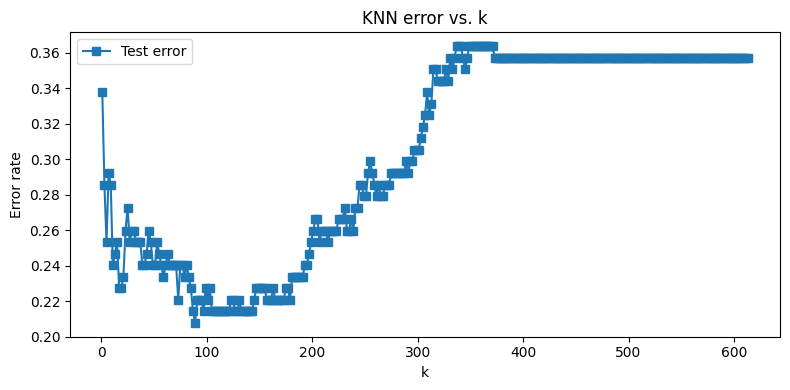

Best K value: 89
Best accuracy value: 0.7922077922077922


In [34]:
k_values = range(1, 614, 2)
test_errors = []
best_k = 0
best_acc = 0.0

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test,  m.predict(X_test_scaled))
    test_errors.append( 1 - accuracy_score(y_test,  m.predict(X_test_scaled)))
    if acc > best_acc:
        best_k, best_acc = k, acc

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), test_errors,  marker='s', label='Test error')
plt.xlabel('k')
plt.ylabel('Error rate')
plt.title('KNN error vs. k')
plt.legend()
plt.tight_layout()
plt.show()

print('Best K value:', best_k)
print('Best accuracy value:', best_acc)

## Train the model

In [30]:
classifier = KNeighborsClassifier(n_neighbors=89)
classifier.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",89
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Predict on test data

In [31]:
y_pred = classifier.predict(X_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

## Evaluate the model

Accuracy: 0.7922


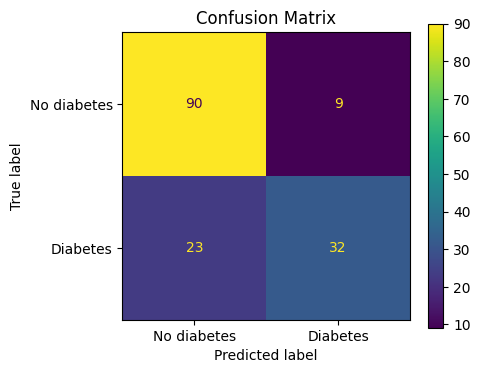

In [32]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# For medical diagnosis, look beyond accuracy.
# False Negatives (diabetic predicted as healthy) are more costly than False Positives.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No diabetes', 'Diabetes']).plot(ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()